# 🔗 Innovation Relatedness Density Analysis

In Economic Complexity, **Relatedness Density** quantifies how close a country is to a new field based on its existing innovation capabilities.

- **Relatedness Density**: Measures the proximity of a country's current specialized fields to a specific field. High density indicates that a country already possesses many of the related capabilities needed to succeed in that field.
- **Strategic Opportunities**: We look for fields where a country has **High Relatedness Density** but no **Comparative Advantage (RCA < 1)** yet. These are "easy wins" or natural next steps for diversification.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ecomplexity import ecomplexity
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
print('✅ Libraries loaded')

✅ Libraries loaded


## 1. Load Data
We will load all available dimensions (**Production, Technology, Science, Entrepreneurial**) for the year **2023** to compare relatedness across different types of innovation.

In [2]:
# Load mapping files
fields = pd.read_parquet('data/fields.parquet')
units = pd.read_parquet('data/units.parquet')

# Load output data
outputs = pd.read_parquet('data/outputs.parquet')

# Filter for all dimensions in 2023
data_2023 = outputs[(outputs['Period'] == 2023)].copy()
print(f"Loaded {len(data_2023):,} rows for 2023 across {data_2023['Dimension'].nunique()} dimensions")

Loaded 293,278 rows for 2023 across 4 dimensions


## 2. Calculate E-Complexity Indices
We calculate the indices for each dimension separately to ensure proper normalization, then combine the results.

In [3]:
trade_cols = {'time': 'Period', 'loc': 'Unit', 'prod': 'Field ID', 'val': 'Outputs (Fractional)'}
results_list = []

for dim in data_2023['Dimension'].unique():
    dim_data = data_2023[data_2023['Dimension'] == dim]
    print(f"Calculating complexity for Dimension: {dim}...")
    res = ecomplexity(dim_data[trade_cols.values()], trade_cols)
    res['Dimension'] = dim
    results_list.append(res)

complexity_results = pd.concat(results_list, ignore_index=True)

# Merge with field names and dimension names
complexity_results = complexity_results.merge(
    fields[['Field ID', 'Field Name', 'Dimension Name']], 
    on='Field ID', 
    how='left'
)

print("✅ All metrics calculated and merged")

Calculating complexity for Dimension: P...
2023
Percentage of pairs compared that meet log-supermodularity condition: 38.11%
Calculating complexity for Dimension: T...
2023
Percentage of pairs compared that meet log-supermodularity condition: 4.94%
Calculating complexity for Dimension: S...
2023
Percentage of pairs compared that meet log-supermodularity condition: 27.73%
Calculating complexity for Dimension: E...
2023
Percentage of pairs compared that meet log-supermodularity condition: 26.15%
✅ All metrics calculated and merged


## 3. Identify Strategic Opportunities for Chile
We filter for **Chile (CL)** and look for fields where it lacks RCA but has high **Relatedness Density**.

In [4]:
iso = 'CL'
chile_data = complexity_results[complexity_results['Unit'] == iso].copy()

# Convert density to percentage for better readability
chile_data['relatedness_density_pct'] = chile_data['density'] * 100
chile_data['is_specialized'] = chile_data['rca'] > 1

# Filter for opportunities (RCA < 1)
opps = chile_data[chile_data['rca'] < 1].sort_values('density', ascending=False)

print(f"Top 10 Strategic Opportunities for Chile (by Relatedness Density):")
opps[['Field Name', 'Dimension Name', 'relatedness_density_pct', 'pci']].head(10)

Top 10 Strategic Opportunities for Chile (by Relatedness Density):


,Field Name,Dimension Name,relatedness_density_pct,pci
272282,Global Maternal and Child Health Research,Science,50.182494,-2.609155
272306,Epidemiology and Management of Viral Diseases,Science,49.727992,-2.371927
272371,Comprehensive Analysis of Nutrition and Health,Science,49.706253,-1.738128
272448,"Violence, Abuse, and Harassment: Prevalence, I...",Science,49.626907,-2.132069
272207,Environmental Impact and Health Effects of Hea...,Science,49.567453,0.526737
272285,"Infectious Diseases: Epidemiology, Pathogenesi...",Science,49.459332,-2.436098
272537,Sustainable Rural Livelihoods,Science,49.383840,-1.226151
271988,"Regulation, Competition, and Corporate Influen...",Science,49.324687,-1.887975
271938,"Ecology, Evolution, and Conservation of Animal...",Science,49.146540,-1.816836
272231,Antimicrobial Resistance and Microbial Impact ...,Science,49.051311,-1.522619


## 4. Visualizing the Opportunity Space
In this plot, we color the fields by their **Dimension** and represent **Relatedness Density** as a percentage. This allows us to see which areas (Production, Technology, etc.) offer the most immediate paths for diversification.

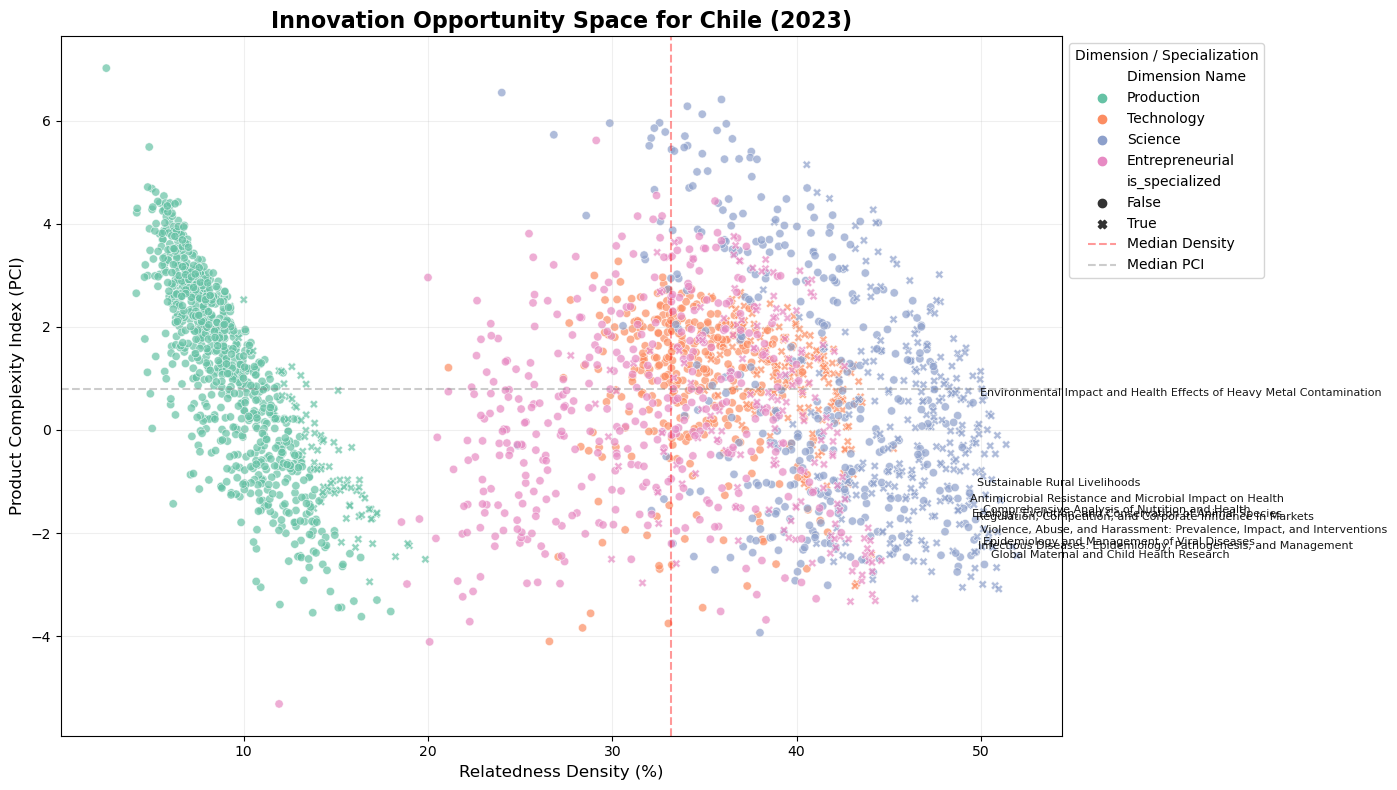

In [5]:
plt.figure(figsize=(14, 8))

# Plotting the opportunity space colored by Dimension
scatter = sns.scatterplot(
    data=chile_data, 
    x='relatedness_density_pct', 
    y='pci', 
    hue='Dimension Name', 
    style='is_specialized', 
    markers={True: 'X', False: 'o'},
    alpha=0.7, 
    palette='Set2'
)

plt.axvline(chile_data['relatedness_density_pct'].median(), color='red', linestyle='--', alpha=0.4, label='Median Density')
plt.axhline(chile_data['pci'].median(), color='gray', linestyle='--', alpha=0.4, label='Median PCI')

plt.title('Innovation Opportunity Space for Chile (2023)', fontsize=16, fontweight='bold')
plt.xlabel('Relatedness Density (%)', fontsize=12)
plt.ylabel('Product Complexity Index (PCI)', fontsize=12)

plt.legend(title='Dimension / Specialization', loc='upper left', bbox_to_anchor=(1, 1))

# Annotate top opportunities across dimensions
for i, row in opps.head(10).iterrows():
    plt.annotate(row['Field Name'], (row['relatedness_density_pct'], row['pci']), 
                 xytext=(5, 5), textcoords='offset points', fontsize=8, alpha=0.9)

plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 5. Summary of Relatedness by Dimension
Comparing average Relatedness Density across different innovation dimensions for Chile.

In [6]:
dim_summary = chile_data.groupby('Dimension Name')['relatedness_density_pct'].mean().sort_values(ascending=False)
print("Average Relatedness Density (%) by Dimension for Chile:")
print(dim_summary)

Average Relatedness Density (%) by Dimension for Chile:
Dimension Name
Science            43.107519
Technology         36.129393
Entrepreneurial    32.907591
Production          9.529717
Name: relatedness_density_pct, dtype: float64
